# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">Agglomerative Hierarchical Clustering Real-World Use Case: Customer Segmentation
</p>
Agglomerative Hierarchical Clustering is an unsupervised machine learning technique that groups similar data points based on their characteristics without requiring predefined class labels. By iteratively merging the most similar observations, the algorithm identifies natural groupings within the dataset and represents them in a hierarchical structure.

In this project, Agglomerative Hierarchical Clustering is applied to a grocery retailer's customer database to perform customer segmentation. Customer segmentation is the process of dividing customers into distinct groups based on similarities in their demographic characteristics and purchasing behavior. The resulting customer segments enable the business to better understand its customer base, personalize products and marketing strategies, improve customer engagement, and allocate resources more effectively by addressing the specific needs and preferences of each segment.


   <a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">TABLE OF CONTENTS</p>   
    
* [1. IMPORTING LIBRARIES](#1)
    
* [2. About the Dataset](#2)

* [3. LOADING DATA](#3)
    
* [4. DATA CLEANING](#4)
    
* [5. DATA PREPROCESSING](#5)   
    
* [6. DIMENSIONALITY REDUCTION](#6) 
      
* [7. AGGLOMERATIVE CLUSTERING](#7)
  
* [8. Dendrogram Analysis and Silhouette Score](#8)

* [9. Comparing Linkage Methods](#9)
    
* [10.EVALUATING MODELS](#10)
    
* [11.PROFILING](#11)
    
* [12.CLUSTER PROFILING](#12)

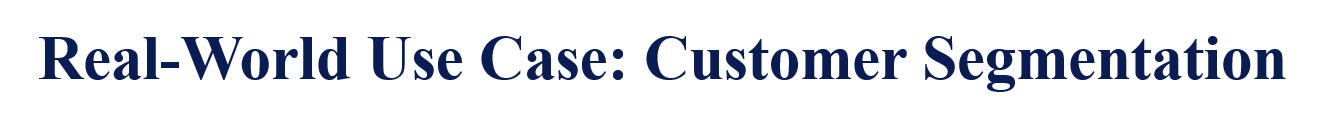
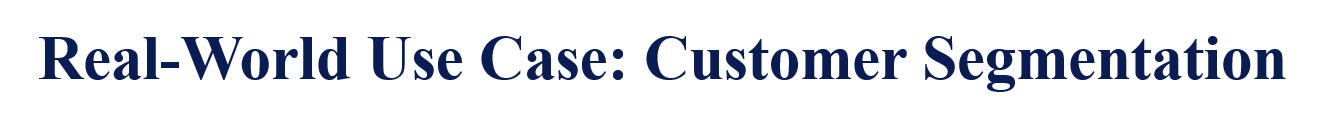
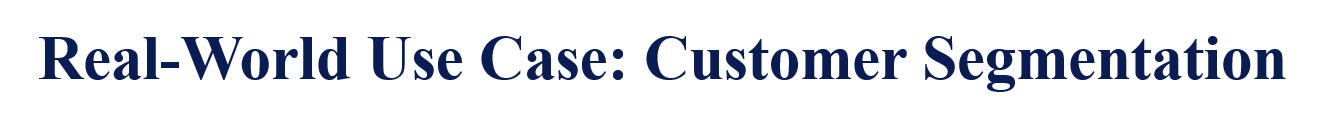
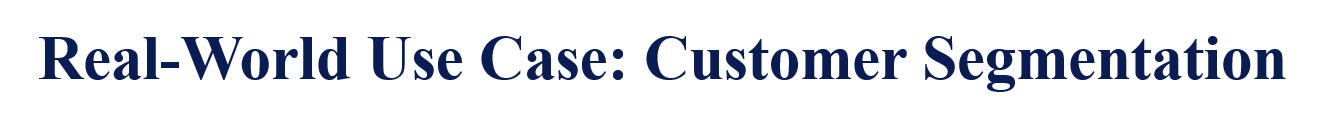

<a id="1"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">IMPORTING LIBRARIES</p>

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)


<a id="2"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">About the Dataset</p>

The dataset consists of 2,240 customer records and 29 attributes. It contains customer demographic information, purchasing behavior, shopping channels, and marketing campaign responses. The features can be categorized into four main groups.

**1. Customer Information**

These features describe the demographic and general characteristics of each customer:


* ID: Unique customer identifier.Year_Birth: Customer's year of birth.
* Education: Customer's education level.
* Marital_Status: Customer's marital status.
* Income: Customer's yearly household income.
* Kidhome: Number of children in the household.
* Teenhome: Number of teenagers in the household.
* Dt_Customer: Date when the customer enrolled with the company.
* Recency: Number of days since the customer's last purchase.
* Complain: Indicates whether the customer complained.

**2. Product Spending**

These features represent the amount spent by the customer on different product categories during the last two years:


* MntWines: Amount spent on wine.
* MntFruits: Amount spent on fruits.
* MntMeatProducts: Amount spent on meat products.
* MntFishProducts: Amount spent on fish products.
* MntSweetProducts: Amount spent on sweet products.
* MntGoldProds: Amount spent on gold products.


**3. Promotion and Campaign Response**

These features describe the customer's interaction with discounts and marketing campaigns:


* NumDealsPurchases: Number of purchases made using a discount.
* AcceptedCmp1: Indicates whether the customer accepted Campaign 
* AcceptedCmp2: Indicates whether the customer accepted Campaign 
* AcceptedCmp3: Indicates whether the customer accepted Campaign 
* AcceptedCmp4: Indicates whether the customer accepted Campaign 
* AcceptedCmp5: Indicates whether the customer accepted Campaign 
* Response: Indicates whether the customer accepted the most recent campaign

**4. Purchase Channels**

These features describe where and how customers make purchases:


* NumWebPurchases: Number of purchases made through the company's website.
* NumCatalogPurchases: Number of purchases made using a catalog.
* NumStorePurchases: Number of purchases made directly in stores.
* NumWebVisitsMonth: Number of visits to the company's website during the last month.


**Dataset Objective**

The objective of this dataset is to identify groups of customers with similar demographic characteristics and purchasing behavior. Since no predefined customer segment labels are available, the problem is treated as an unsupervised clustering problem.

<a id="2"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">LOADING DATA</p>

In [ ]:
#Loading the dataset
data = pd.read_csv("data/marketing_campaign.csv", sep="\t")
print("Number of datapoints:", len(data))
data.head()





<a id="3"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">DATA CLEANING</p>

### In This Section

* Data Cleaning
* Feature Engineering
  
Before applying clustering, the dataset is prepared to improve data quality and feature relevance. This section focuses on cleaning incomplete or inconsistent data, handling outliers, and transforming raw customer information into more meaningful features through feature engineering.

The main workflow is:

Inspect Data → Clean Data → Handle Outliers → Engineer Meaningful Features → Prepare for Preprocessing

In [5]:
#Information on features 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**From the above output, we can conclude and note that:**

* There are missing values in income
* Dt_Customer that indicates the date a customer joined the database is not parsed as DateTime
* There are some categorical features in our data frame; as there are some features in dtype: object). So we will need to encode them into numeric forms later. 

First of all, for the missing values, I am simply going to drop the rows that have missing income values. 

In [6]:
#To remove the NA values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In the next step, I am going to create a feature out of **"Dt_Customer"** that indicates the number of days a customer is registered in the firm's database. However, in order to keep it simple, I am taking this value relative to the most recent customer in the record. 

Thus to get the values I must check the newest and oldest recorded dates. 

In [7]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"])
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)  
#Dates of the newest and oldest recorded customer
print("The newest customer's enrolment date in therecords:",max(dates))
print("The oldest customer's enrolment date in the records:",min(dates))


The newest customer's enrolment date in therecords: 2014-12-06
The oldest customer's enrolment date in the records: 2012-01-08


Creating a feature **("Customer_For")** of the number of days the customers started to shop in the store relative to the last recorded date

In [8]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

Now we will be exploring the unique values in the categorical features to get a clear idea of the data.  

In [9]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64 

Total categories in the feature Education:
 Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: Education, dtype: int64


**Feature Engineering**

* Extract the **"Age"** of a customer by the **"Year_Birth"** indicating the birth year of the respective person.
* Create another feature **"Spent"** indicating the total amount spent by the customer in various categories over the span of two years.
* Create another feature **"Living_With"** out of **"Marital_Status"** to extract the living situation of couples.
* Create a feature **"Children"** to indicate total children in a household that is, kids and teenagers.
* To get further clarity of household, Creating feature indicating **"Family_Size"**
* Create a feature **"Is_Parent"** to indicate parenthood status
* Lastly, I will create three categories in the **"Education"** by simplifying its value counts.
* Dropping some of the redundant features

In [ ]:
#Feature Engineering
#Age of customer today (relative to the current year)
reference_year = datetime.datetime.now().year
data["Age"] = reference_year - data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

Now that we have some new features let's have a look at the data's stats. 

In [12]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,4.423735e+16,52.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,2.008532e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,25.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,2.937600e+16,44.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,4.432320e+16,51.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,5.927040e+16,62.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,9.184320e+16,128.000000,2525.000000,3.000000,5.000000,1.000000


The above stats show some discrepancies in mean Income and Age and max Income and age.



I will take a look at the broader view of the data , and plot some of the selected features.

Reletive Plot Of Some Selected Features: A Data Subset


<Figure size 576x396 with 0 Axes>

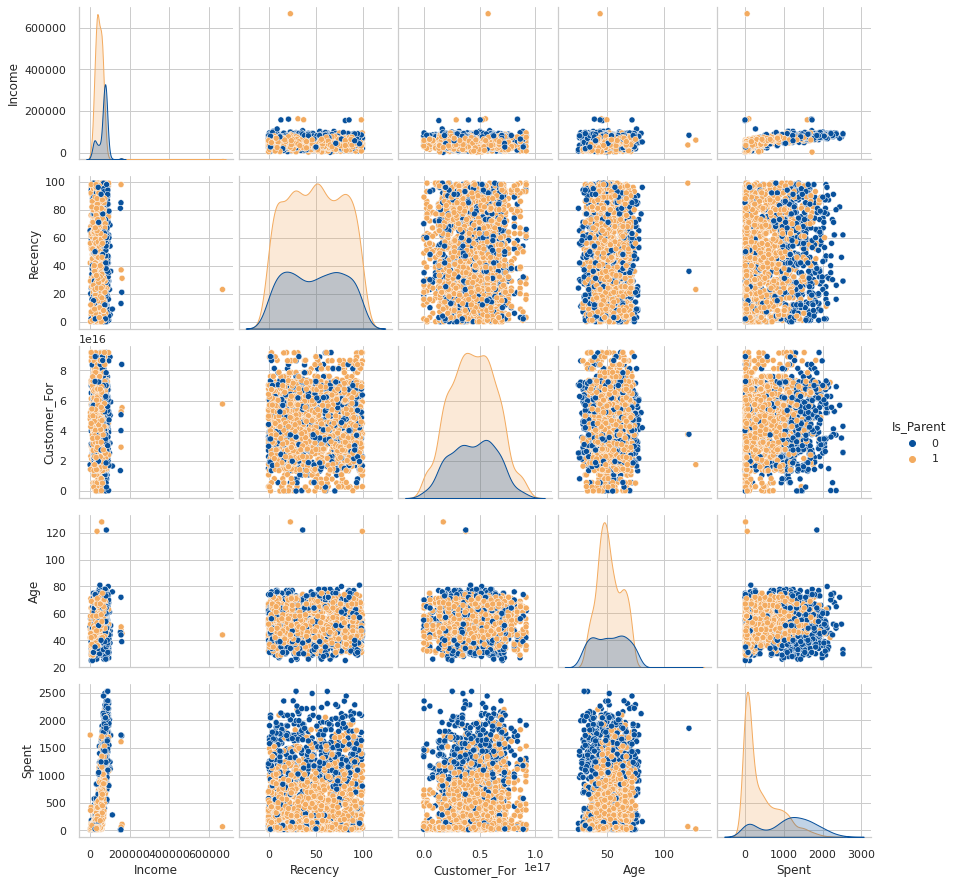

In [13]:
#To plot some selected features 
#Setting up colors prefrences
sns.set_theme(style="whitegrid")
pallet = sns.color_palette("deep", 6)
cmap = "viridis"
#Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Reletive Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= (["#08519C","#F3AB60"]))
#Taking hue 
plt.show()

Clearly, there are a few outliers in the Income and Age features. 
I will be deleting the outliers in the data. 

In [14]:
#Dropping the outliers by setting a cap on Age and income. 
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


Next, let us look at the correlation amongst the features. 
(Excluding the categorical attributes at this point)

<AxesSubplot:>

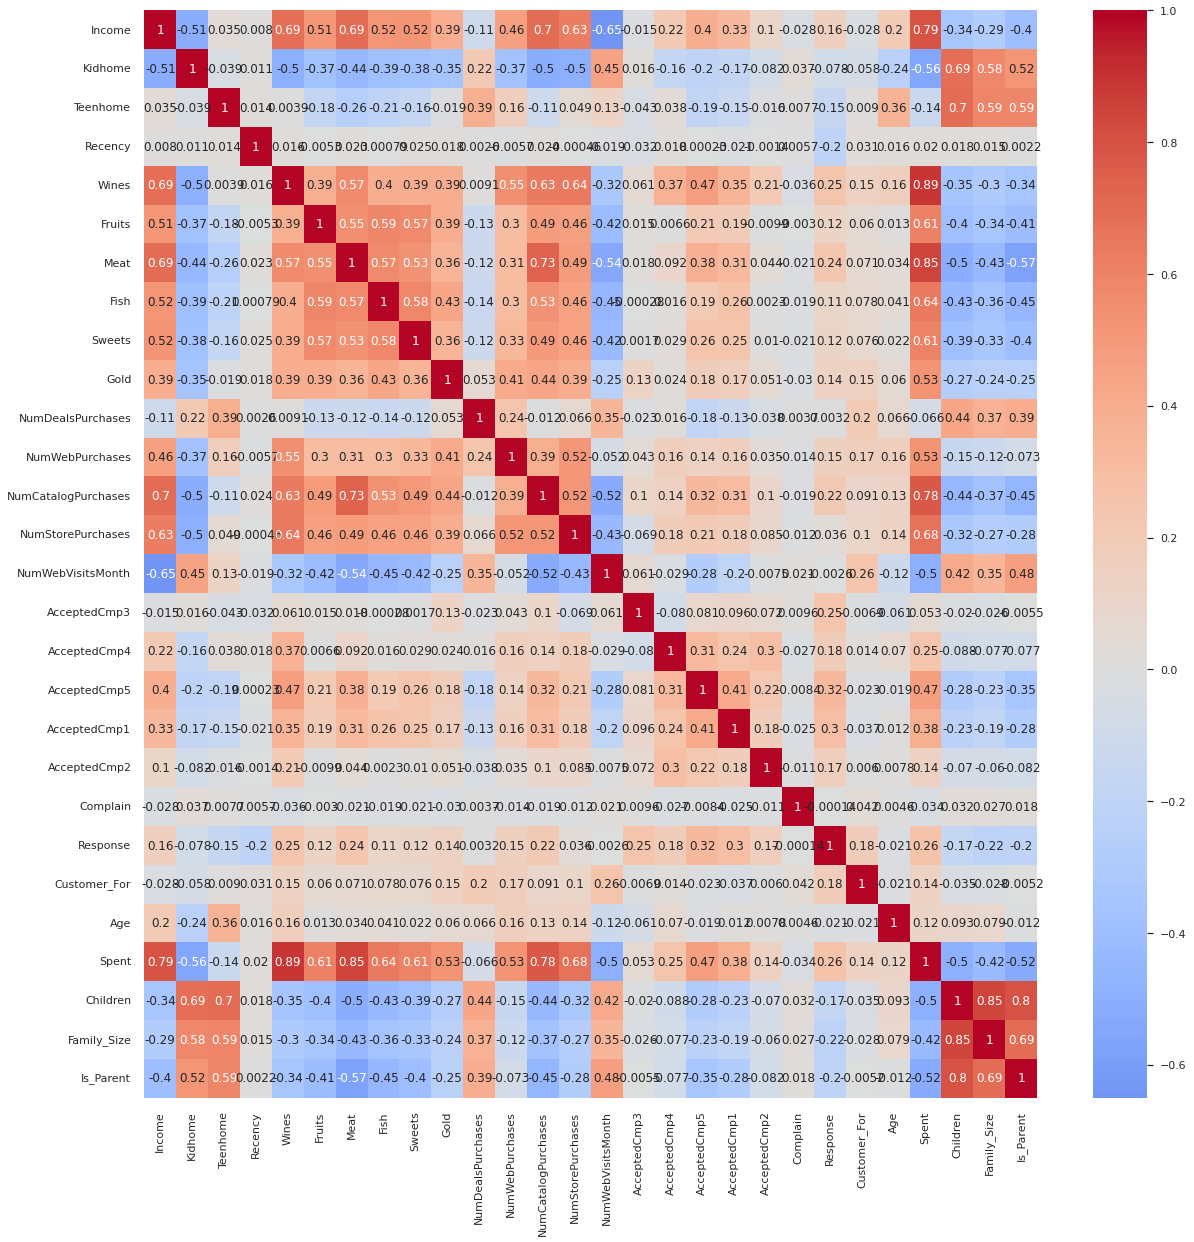

In [15]:
#correlation matrix
corrmat= data.corr()
plt.figure(figsize=(20,20))  
sns.heatmap(corrmat,annot=True, cmap="coolwarm", center=0)

The data is quite clean and the new features have been included. I will proceed to the next step. That is, preprocessing the data. 

<a id="4"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">DATA PREPROCESSING</p>

### In This Section

Before applying clustering, the dataset is prepared to improve **data quality and feature relevance**. This section focuses on cleaning incomplete or inconsistent data, handling outliers, and transforming raw customer information into more meaningful features through feature engineering.

The main workflow is:

**Inspect Data → Clean Data → Handle Outliers → Engineer Meaningful Features → Prepare for Preprocessing**


In [16]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [17]:
#Label Encoding the object dtypes.
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)
    
print("All features are now numerical")

All features are now numerical


In [18]:
#Creating a copy of data
ds = data.copy()
# creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)
#Scaling
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
print("All features are now scaled")

All features are now scaled


In [19]:
#Scaled data to be used for reducing the dimensionality
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.973583,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.665144,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.172664,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.923210,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.822130,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


<a id="5"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">DIMENSIONALITY REDUCTION</p>

The selected dataset contains multiple customer features, some of which are correlated and may contain redundant information. Working with a high number of features can increase data complexity and affect distance-based clustering.

To simplify the feature space while preserving the main patterns in the data, Principal Component Analysis (PCA) is applied before Agglomerative Clustering.

PCA transforms the original features into a smaller set of uncorrelated principal components that capture the main variance in the dataset.

**Steps in this section:**


* Apply PCA for dimensionality reduction.
* Analyze the explained variance of the principal components.
* Reduce the dataset to 3 principal components.
* Visualize the transformed data in a 3D PCA space.


**Workflow:**

Scaled Features → PCA Transformation → 3 Principal Components → 3D Visualization → Agglomerative Clustering

In [20]:
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,-1.116246e-16,2.878377,-5.969394,-2.538494,-0.780421,2.383290,7.444305
col2,2212.0,1.105204e-16,1.706839,-4.312196,-1.328316,-0.158123,1.242289,6.142721
col3,2212.0,3.049098e-17,1.221956,-3.530416,-0.829067,-0.022692,0.799895,6.611222


In [21]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print(
    "Total Explained Variance:",
    explained_variance.sum()
)

Explained Variance Ratio:
[0.36005684 0.12660793 0.064891  ]
Total Explained Variance: 0.5515557667734585


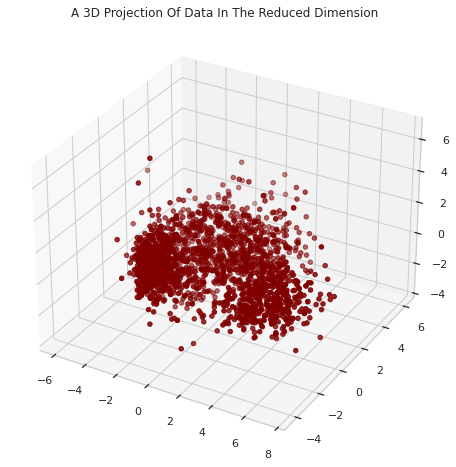

In [22]:
#A 3D Projection Of Data In The Reduced Dimension
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

<a id="6"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">Agglomerative Hierarchical Clustering</p>

### Agglomerative Clustering

After reducing the dataset to **three principal components**, Agglomerative Clustering is applied to identify groups of customers with similar characteristics.

Agglomerative Clustering is a **bottom-up hierarchical clustering method**. It starts by treating each observation as an individual cluster and progressively merges the closest clusters based on the selected **linkage criterion**. The merging process continues until the desired number of clusters is reached.

In this analysis, **Ward Linkage** is used to merge clusters while minimizing the increase in **within-cluster variance**.

**Steps involved in this section:**

* Perform **Dendrogram Analysis** to examine the hierarchical cluster structure.
* Calculate the **Silhouette Score for different numbers of clusters**.
* Select the optimal number of clusters based on the dendrogram and Silhouette Score.
* Apply **Agglomerative Clustering using Ward Linkage**.
* Visualize the resulting clusters in the **3D PCA space**.

**Workflow:**

**PCA-Reduced Data → Dendrogram Analysis → Silhouette Score Analysis → Select Number of Clusters → Ward Agglomerative Clustering → Cluster Visualization**


### Algorithm steps

1. Start with each data point as a separate cluster.
2. Compute distances between clusters.
3. Merge the two closest clusters according to the selected linkage method.
4. Recalculate distances after the merge.
5. Repeat until the desired number of clusters is reached.

### Why this is different from KMeans

KMeans starts with a fixed number of centroids and repeatedly updates them. Agglomerative Clustering does not start with centroids. Instead, it builds a hierarchy of merges. This is why the dendrogram is central in Agglomerative Clustering.

### Linkage methods

The linkage method defines how the distance between two clusters is calculated.

#### Single linkage
Uses the minimum distance between points from two clusters:

$$D(A,B)=\min_{a \in A, b \in B} d(a,b)$$

It can suffer from the chaining effect.

#### Complete linkage
Uses the maximum distance between points from two clusters:

$$D(A,B)=\max_{a \in A, b \in B} d(a,b)$$

It tends to create compact clusters.

#### Average linkage
Uses the average pairwise distance between all points in two clusters:



#### Ward linkage
Merges clusters that cause the smallest increase in within-cluster variance. Ward linkage is commonly used with Euclidean distance and often produces compact, balanced clusters.


## Dendrogram Analysis and Silhouette Score


A dendrogram visualizes the hierarchical merging process of Agglomerative Clustering. Large vertical gaps indicate merges between relatively distant groups and can help identify a suitable number of clusters.

**Linkage used in this notebook: Ward linkage.** The original `AgglomerativeClustering(n_clusters=4)` uses scikit-learn's default `linkage='ward'`. Ward linkage merges the pair of clusters that causes the smallest increase in within-cluster variance. With Ward linkage, Euclidean distance is used.

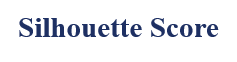
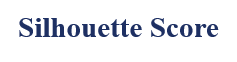
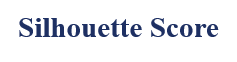
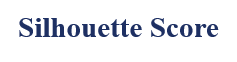

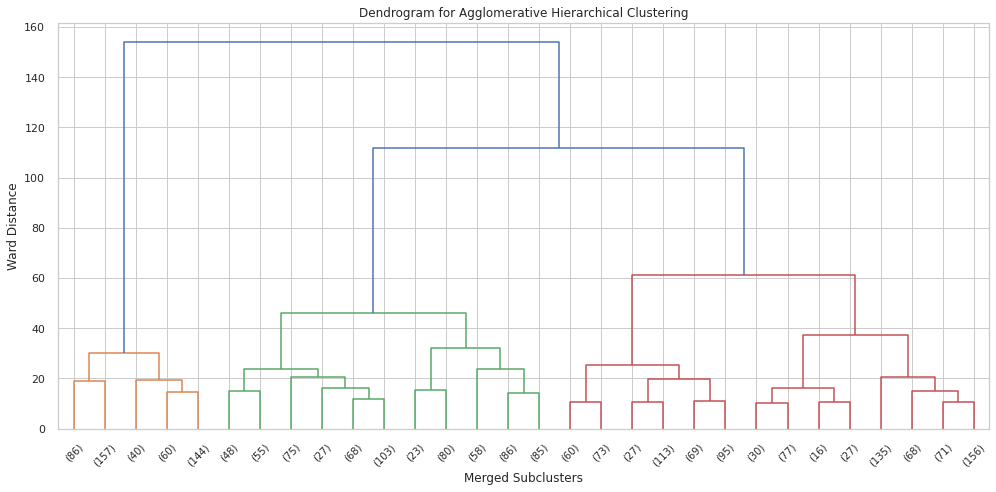

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Build the hierarchical linkage matrix using Ward linkage
X_hier = PCA_ds.drop(columns=['Clusters'], errors='ignore')
Z = linkage(X_hier, method='ward')

# Plot the dendrogram
plt.figure(figsize=(14, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10)
plt.title('Dendrogram for Agglomerative Hierarchical Clustering')
plt.xlabel('Merged Subclusters')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.show()

### Interpreting the Dendrogram

- Read the dendrogram from bottom to top: individual observations or subclusters are progressively merged.
- The height of a merge represents the dissimilarity between the merged groups.
- A large vertical gap suggests strong separation between clusters.
- A horizontal cut can be used to estimate the number of clusters; the number of branches crossed represents the selected clusters.
- The dendrogram should be considered together with internal validation metrics when choosing the final number of clusters.

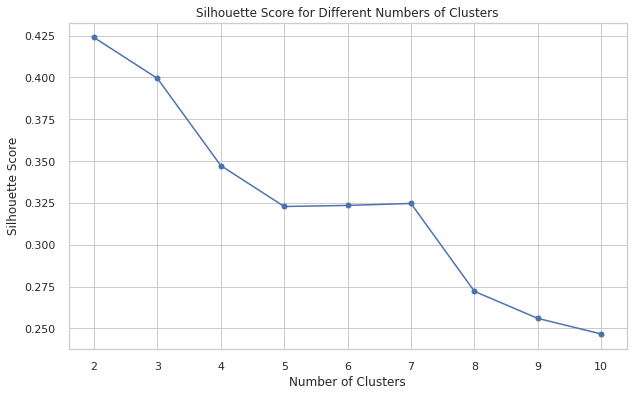

In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Data used for clustering
X_cluster = PCA_ds.drop(columns=['Clusters'], errors='ignore')

# Test different numbers of clusters
cluster_range = range(2, 11)
silhouette_scores = []

for k in cluster_range:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = model.fit_predict(X_cluster)
    
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))

plt.plot(
    cluster_range,
    silhouette_scores,
    marker='o'
)

plt.title(
    'Silhouette Score for Different Numbers of Clusters'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.xticks(cluster_range)

plt.show()

## Comparing Linkage Methods

Agglomerative Clustering can produce different hierarchical structures depending on the linkage criterion. The following comparison evaluates Ward, Complete, Average, and Single linkage using the Silhouette Score and Davies-Bouldin Index.

In [25]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

X_linkage = PCA_ds.drop(columns=['Clusters'], errors='ignore')
linkage_results = []

for method in ['ward', 'complete', 'average', 'single']:
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    linkage_labels = model.fit_predict(X_linkage)
    linkage_results.append({
        'Linkage': method.title(),
        'Silhouette Score': silhouette_score(X_linkage, linkage_labels),
        'Davies-Bouldin Index': davies_bouldin_score(X_linkage, linkage_labels)
    })

linkage_comparison = pd.DataFrame(linkage_results)
linkage_comparison

,Linkage,Silhouette Score,Davies-Bouldin Index
0,Ward,0.347296,0.975051
1,Complete,0.271287,1.206202
2,Average,0.324176,0.673362
3,Single,0.136797,0.471050


In [26]:
#Initiating the Agglomerative Clustering model 
AC = AgglomerativeClustering(n_clusters=4, linkage='ward')
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_AC

To examine the clusters formed let's have a look at the 3-D distribution of the clusters. 

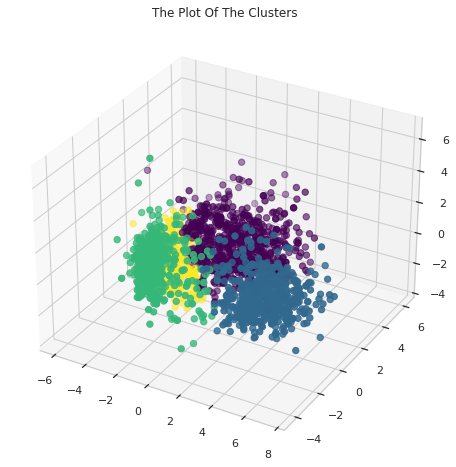

In [27]:
#Plotting the clusters
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

<a id="7"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">EVALUATING MODELS</p>

Since this is an unsupervised clustering task, there is no ground truth or target variable available to directly measure prediction accuracy. Instead, the quality of the clustering model is evaluated using internal validation metrics, including the **Silhouette Score**, **Davies-Bouldin Index**, and **Cluster Size Balance**, which assess the cohesion, separation, and distribution of the generated clusters.

Following the quantitative evaluation, exploratory data analysis is used to examine the characteristics of each cluster, identify customer patterns, and interpret the business meaning of the resulting customer segments. This combination of internal validation metrics and cluster profiling provides a comprehensive assessment of the clustering model's performance.


In [28]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Features used for clustering
X = PCA_ds.drop("Clusters", axis=1)

# Cluster labels
labels = PCA_ds["Clusters"]

# -----------------------------
# 1. Silhouette Score
# -----------------------------
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.4f}")

# -----------------------------
# 2. Davies-Bouldin Index
# -----------------------------
db_score = davies_bouldin_score(X, labels)
print(f"Davies-Bouldin Index: {db_score:.4f}")

# -----------------------------
# 3. Cluster Size Balance
# -----------------------------
cluster_sizes = labels.value_counts().sort_index()

print("\nCluster Sizes:")
print(cluster_sizes)

print("\nCluster Percentage Distribution:")
print((cluster_sizes / len(labels) * 100).round(2).astype(str) + "%")

Silhouette Score: 0.3473
Davies-Bouldin Index: 0.9751

Cluster Sizes:
0    708
1    487
2    580
3    437
Name: Clusters, dtype: int64

Cluster Percentage Distribution:
0    32.01%
1    22.02%
2    26.22%
3    19.76%
Name: Clusters, dtype: object


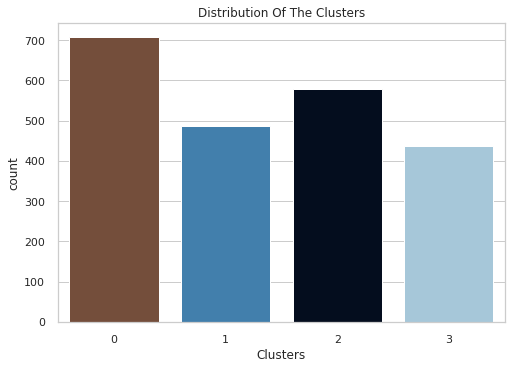

In [29]:
#Plotting countplot of clusters
pal = ["#7D4B32","#3182BD", "#000C22","#9ECAE1"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

The clusters seem to be fairly distributed.

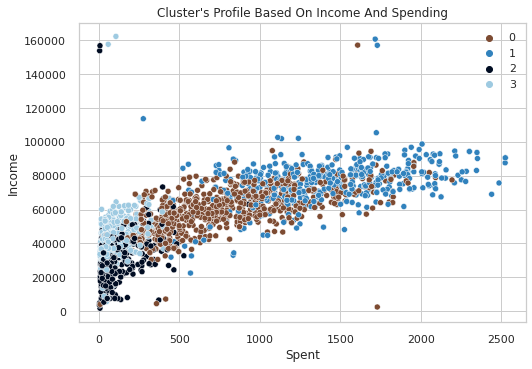

In [30]:
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

**Cluster Interpretation Based on Income and Spending**

**Cluster 0 – Middle-Income, Moderate-to-High Spending Customers**

* Customers have moderate to high income (approximately $35,000–$90,000).
* Spending levels range from moderate to high, indicating consistent purchasing behavior.
* Represents the retailer's core customer segment.
* Likely to respond well to loyalty programs, personalized recommendations, and seasonal promotions.



**Cluster 1 – High-Income, High-Spending Customers**

* Customers have the highest spending levels in the dataset.
* Generally earn high incomes, indicating strong purchasing power.
* Represents the retailer's premium or high-value customers.
* Ideal targets for exclusive offers, premium products, VIP memberships, and customer retention campaigns.



**Cluster 2 – Low-Income, Low-Spending Customers**

* Customers have low income and low overall spending.
* Most observations are concentrated near the lower end of both income and spending.
* Represents budget-conscious and price-sensitive customers.
* More likely to respond to discounts, promotional pricing, and value-based product offerings.



**Cluster 3 – Moderate-Income, Low-Spending Customers**


* Customers have moderate income but maintain relatively low spending levels.
* Their purchasing behavior is lower than expected given their income.
* Represents under-engaged or occasional customers.
* Provides an opportunity to increase sales through targeted marketing, personalized promotions, and customer engagement strategies.


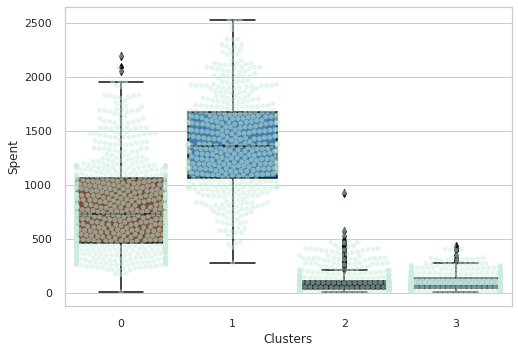

In [34]:
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()


From the above plot, it can be clearly seen that cluster 1 is our biggest set of customers closely followed by cluster 0.
We can explore what each cluster is spending on for the targeted marketing strategies.


Let us next explore how did our campaigns do in the past.

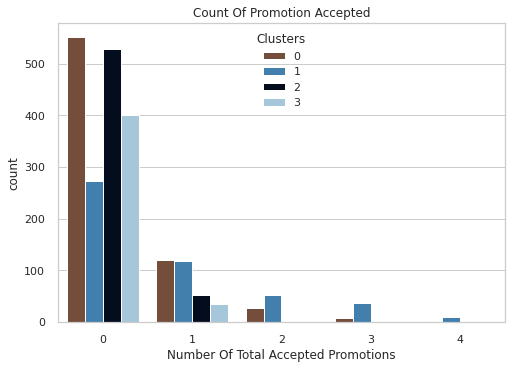

In [32]:
#Creating a feature to get a sum of accepted promotions 
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]
#Plotting count of total campaign accepted.
plt.figure()
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

There has not been an overwhelming response to the campaigns so far. Very few participants overall. Moreover, no one part take in all 5 of them. Perhaps better-targeted and well-planned campaigns are required to boost sales. 


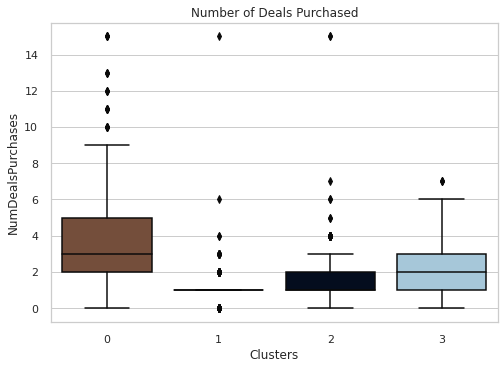

In [33]:
# Plotting the number of deals purchased
plt.figure()

pl = sns.boxplot(
    y=data["NumDealsPurchases"],
    x=data["Clusters"],
    palette=pal
)

pl.set_title("Number of Deals Purchased")
plt.show()

Unlike campaigns, the deals offered did well. It has best outcome with cluster 0 and cluster 3. 
However, our star customers cluster 1 are not much into the deals. 
Nothing seems to attract cluster 2 overwhelmingly 


<Figure size 576x396 with 0 Axes>

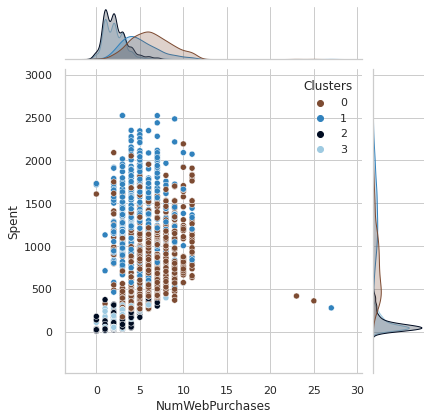

<Figure size 576x396 with 0 Axes>

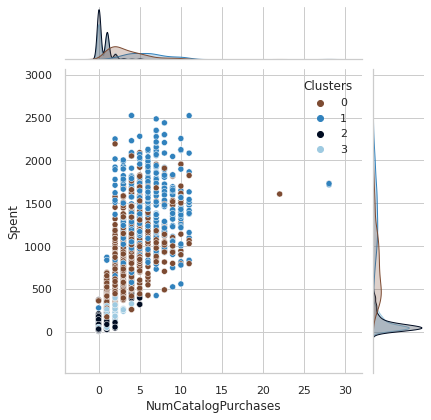

<Figure size 576x396 with 0 Axes>

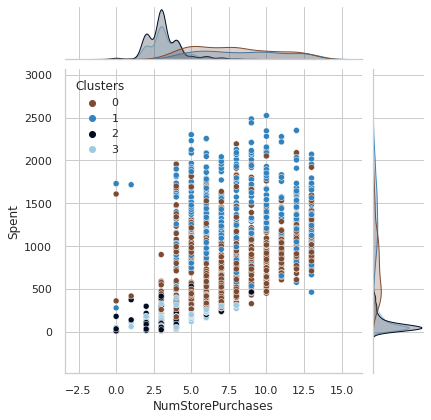

<Figure size 576x396 with 0 Axes>

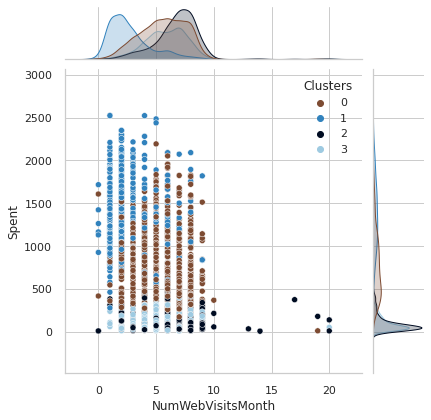

In [42]:
#for more details on the purchasing style 
Places =["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",  "NumWebVisitsMonth"] 

for i in Places:
    plt.figure()
    sns.jointplot(x=data[i],y = data["Spent"],hue=data["Clusters"], palette= pal)
    plt.show()

<a id="8"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">PROFILING</p>

Now that we have formed the clusters and looked at their purchasing habits. 
Let us see who all are there in these clusters. For that, we will be profiling the clusters formed and come to a conclusion about who is our star customer and who needs more attention from the retail store's marketing team.

To decide that I will be plotting some of the features that are indicative of the customer's personal traits in light of the cluster they are in. 
On the basis of the outcomes, I will be arriving at the conclusions. 

<Figure size 576x396 with 0 Axes>

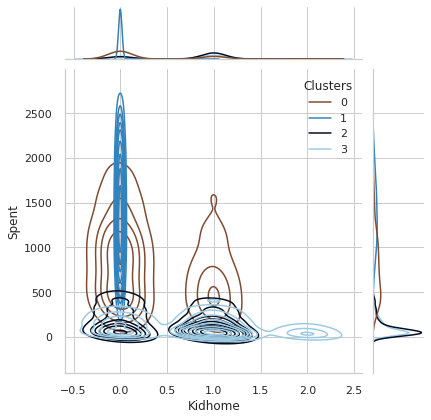

<Figure size 576x396 with 0 Axes>

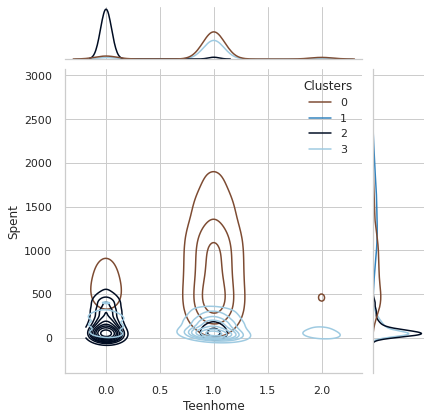

<Figure size 576x396 with 0 Axes>

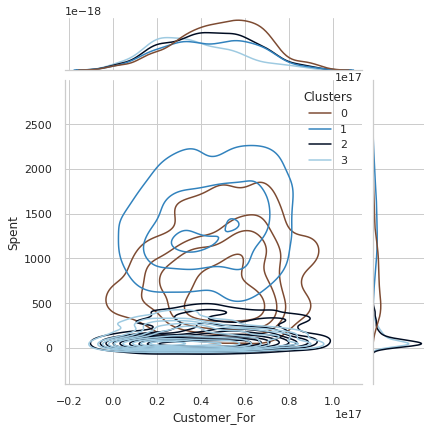

<Figure size 576x396 with 0 Axes>

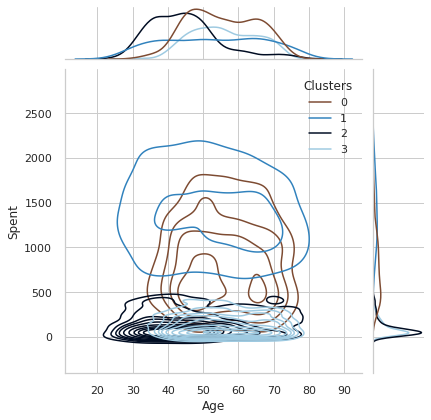

<Figure size 576x396 with 0 Axes>

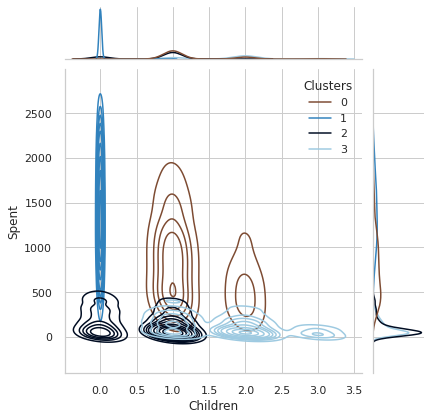

<Figure size 576x396 with 0 Axes>

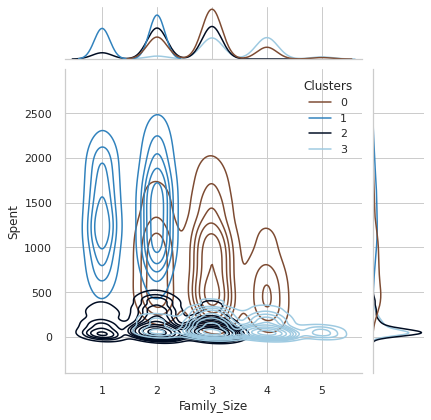

<Figure size 576x396 with 0 Axes>

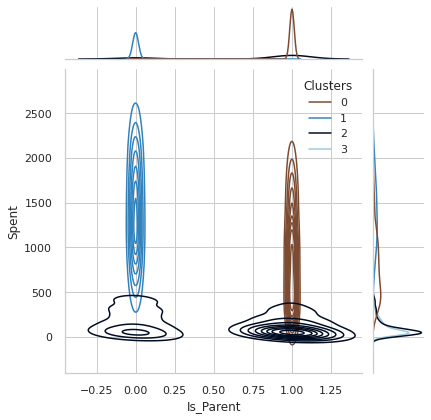

<Figure size 576x396 with 0 Axes>

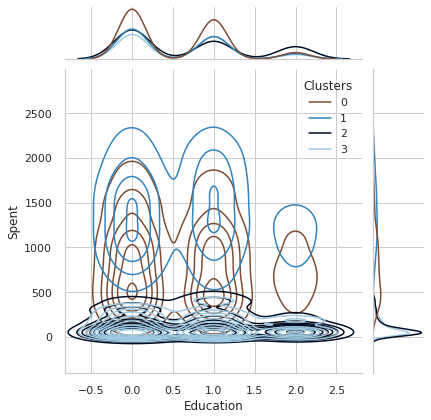

<Figure size 576x396 with 0 Axes>

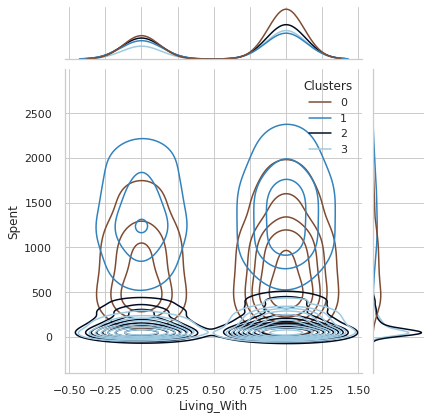

In [39]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette=pal)
    plt.show()

<a id="9"></a>
# <p style="background-color:#203864;font-family:newtimeroman;color:#FFFFFF;font-size:150%;text-align:center;border-radius:10px 10px;">Cluster Profiling</p>

Cluster profiling is the process of analyzing the characteristics of each generated cluster to understand the type of customers it represents.

**Cluster 0 Profile**


* Customers are mainly parents.Most customers have around one child at home.
* Teenagers are commonly present in the household.
* Family size is generally between 2 and 4 members.
* Customers are mainly middle-aged to older adults.
* The cluster contains relatively high-spending customers.


**General Profile:** Parent households with medium-sized families, commonly having children or teenagers and showing relatively high spending.

**Cluster 1 Profile**


* Customers are mainly not parents.
* Most customers have no children or teenagers at home.
* Family size is generally small, mainly 1 to 2 members.
* The cluster includes both individuals and couples.
* Customers belong to different age groups.
* This cluster contains the highest-spending customers.


General Profile: High-spending customers without children, mainly individuals or couples with small households.

**Cluster 2 Profile**


* Customers are mainly concentrated in the low-spending group.
* The cluster contains both parents and non-parents.
* Customers generally have zero or one child.
* Family size is mainly small to medium.
* Customers are mostly younger to middle-aged.
* Demographic characteristics are relatively mixed compared with the other clusters.


**General Profile:** Low-spending customers with mixed family characteristics, mainly younger or middle-aged customers from small to medium households.

**Cluster 3 Profile**


* Customers are mainly parents.
* Customers generally have more children compared with the other clusters.
* Family size is relatively larger, commonly between 3 and 5 members.
* The cluster mainly contains low-spending customers.
* Customers are distributed across different age groups but are commonly middle-aged or older.
* Larger family structures are more common in this cluster.


**General Profile:** Lower-spending parent households with larger families and more children.